# Mini Project

Solutions from:   

Name: **Manoj Billur Nagendra Prasad**   
Matriculation Number: 2886261

Name: **Steffi Stephen**  
Matriculation Number: 4109600

Objectives of this notebook

This notebook trains and evaluates multiple machine learning models using the feature matrix generated during feature engineering. The models are compared using standard classification metrics, and the best-performing model is selected for Explainable AI analysis.

1. Load Feature Matrix
4. Prepare Features and Labels (encode the labels)
6. Train/Test Split (using provided split)
7. Train Baseline Models ----> Logistic Regression, Decision Tree, Random Forest, XGBoost (optional if available)
8. Evaluate Models based on Accuracy, Precision, Recall, F1 Score, Confusion Matrix, Classification Report
9. Compare Models
10. Select Best Model
11. Save Model

This notebook uses the following inputs:

| File | Description |
|------|-------------|
| `feature_matrix.pkl` | Engineered feature matrix |
| `trainingSet.tsv` | Training instances |
| `testSet.tsv` | Test instances |


This notebook generates the following files:

| File | Description |
|------|-------------|
| `random_forest_model.pkl` | Trained Random Forest model |
| `logistic_regression_model.pkl` | Trained Logistic Regression model |
| `label_encoder.pkl` | Encoded class labels |
| `model_comparison.csv` | Model performance comparison |
| `random_forest_confusion_matrix.png` | Confusion matrix visualization |

In [1]:
# =============================================================================
# Project Setup
# =============================================================================

from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd().parent
sys.path.append(str(PROJECT_ROOT))

# Project paths
from utils.paths import *

# =============================================================================
# Third-Party Libraries
# =============================================================================

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import joblib

# Machine Learning Models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

# Evaluation
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

from sklearn.preprocessing import LabelEncoder

# Display all columns
pd.set_option("display.max_columns", None)

# 1) Load Feature Matrix

In [2]:
# ============================================================
# Load Feature Matrix
# ============================================================

feature_df = pd.read_pickle(OUTPUTS_DIR / "feature_matrix.pkl")

print("Feature matrix loaded successfully.")

Feature matrix loaded successfully.


In [3]:
# ============================================================
# Dataset Overview
# ============================================================

print("=" * 60)
print("Feature Matrix Information")
print("=" * 60)

print("Rows   :", feature_df.shape[0])
print("Columns:", feature_df.shape[1])

feature_df.head()

Feature Matrix Information
Rows   : 176
Columns: 183


,Person,Homepage,Publication Count,WorksAtProject Count,Number of Projects,Publication Year,Topic_Artificial_Intelligence,Topic_AspectOriented_Programming,Topic_Business_models,Topic_Computational_Biology,Topic_Computer_Science,Topic_CoursewareEngineering,Topic_Customer_Relationship_Management,Topic_Digital_libraries,Topic_EMS_problems,Topic_FPGA,Topic_Graph_drawing,Topic_Grid_Computing,Topic_IT_controlling,Topic_IT_governance,Topic_Information_Retrieval,Topic_Information_economics,Topic_Law,Topic_Middleware,Topic_MultimediaEngineering,Topic_Multimedia_Annotation_Retrieval,Topic_Natural_Language_Processing,Topic_Ontology_Engineering,Topic_Ontology_engineering_methodology,Topic_Ontology_management,Topic_Optimization_in_the_presence_of_uncertainty,Topic_Organic_Computing,Topic_PeertoPeer,Topic_Petri_nets,Topic_Routing_in_P2P_Systems,Topic_Scalable_Data_Mining,Topic_Semantic_Web_Services,Topic_Web_Services,Topic_agent_systems,Topic_algorithmic_graph_theory,Topic_ant_algorithms,Topic_business_engineering,Topic_business_intelligence,Topic_business_process_analysis,Topic_business_process_management,Topic_business_process_modelling,Topic_business_process_simulation,Topic_complexity_management,Topic_complexity_theory,Topic_computational_finance,Topic_computer_architecture,Topic_data_mining,Topic_database_systems,Topic_decision_support_systems,Topic_deductive_databases,Topic_descriptive_complexity_theory,Topic_development_of_knowledge_management_systems,Topic_distributed_algorithms,Topic_domain_theory,Topic_eLearning,Topic_ebusiness,Topic_efficient_algorithms,Topic_electronic_commerce,Topic_electronic_markets,Topic_evolutionary_algorithms,Topic_evolutionary_optimization_of_dynamic_problems,Topic_formal_concept_analysis,Topic_fuzzy_logic,Topic_genetic_algorithms,Topic_graphminoren,Topic_hardware_algorithms,Topic_human_computer_systems,Topic_hypermedia_systems,Topic_information_extraction,Topic_information_systems,Topic_knowledge_discovery,Topic_knowledge_management,Topic_knowledge_management_methodology,Topic_knowledge_portals,Topic_knowledge_representation_and_reasoning,Topic_knowledge_representation_languages,Topic_knowledge_systems,Topic_learning_modules,Topic_logic,Topic_logic_programming,Topic_machine_learning,Topic_mbusiness,Topic_mobile_technologies,Topic_model_theory,Topic_modeling,Topic_multicriteria_optimization,Topic_multimedia_systems,Topic_natureinspired_algorithms,Topic_neuralsymbolic_integration,Topic_nonmonotonic_reasoning,Topic_objectoriented_programming,Topic_office_information_systems,Topic_ontology_engineering,Topic_ontology_learning,Topic_ontologybased_knowledge_management_systems,Topic_optimization,Topic_parallel_algorithms,Topic_performance_management_systems,Topic_portfolio_management,Topic_reconfigurability,Topic_reconfigurable_mesh,Topic_risk_management,Topic_security,Topic_semantic_annotation,Topic_semantic_web,Topic_semantic_web_infrastructure,Topic_semantical_annotation,Topic_softcomputing,Topic_software_engineering,Topic_software_ergonomics,Topic_stock_value_analysis,Topic_stockexchange_simulation,Topic_systems_engineering,Topic_teaching_modules,Topic_tele_applications,Topic_tele_cooperation,Topic_teleteaching,Topic_text_mining,Topic_theoretic_computer_science,Topic_topology_in_computer_science,Topic_tree_automata,Topic_usability_engineering,Topic_virtual_organizations,Topic_virtual_university,Topic_webbased_Learning,Topic_workflow_management,Topic_www_systems,Conference_001,Conference_002,Conference_003,Conference_004,Conference_005,Conference_006,Conference_007,Conference_008,Conference_009,Conference_010,Conference_011,Conference_012,Conference_013,Conference_014,Conference_015,Conference_016,Conference_017,Conference_018,Conference_019,Conference_020,Conference_021,Conference_022,Conference_023,Conference_024,Conference_025,Conference_026,Conference_027,Conference_028,Conference_029,Conference_030,Conference_031,Conference_032,Conference_033,Conference_034,Conference_035,Conference_036,Conference_037,Co

In [4]:
feature_df.dtypes

Person                  object
Homepage                 int64
Publication Count        int64
WorksAtProject Count     int64
Number of Projects       int64
                         ...  
Conference_047           int64
Conference_048           int64
Conference_049           int64
Conference_050           int64
Research Group          object
Length: 183, dtype: object

In [5]:
print("Total Missing Values:", feature_df.isna().sum().sum())

Total Missing Values: 0


In [6]:
print("Duplicate Persons:", feature_df["Person"].duplicated().sum())

Duplicate Persons: 0


In [7]:
print("=" * 60)
print("Target Distribution")
print("=" * 60)

feature_df["Research Group"].value_counts()

Target Distribution


Research Group
Forschungsgruppen(id1instance)    73
Forschungsgruppen(id3instance)    60
Forschungsgruppen(id2instance)    28
Forschungsgruppen(id4instance)    15
Name: count, dtype: int64

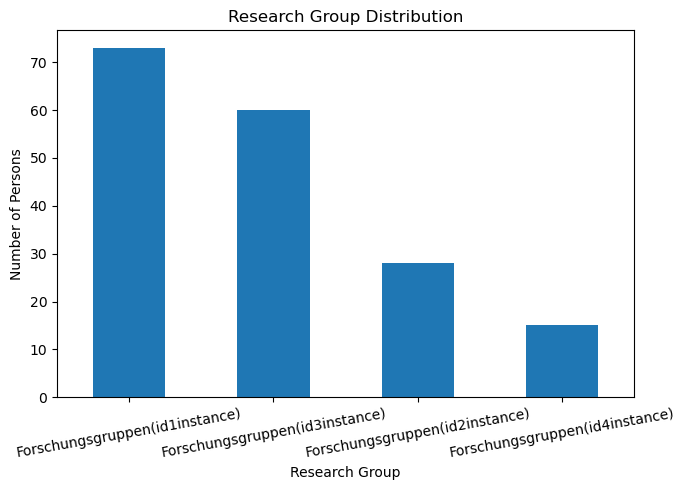

In [8]:
plt.figure(figsize=(7,5))

feature_df["Research Group"].value_counts().plot(
    kind="bar"
)

plt.title("Research Group Distribution")
plt.xlabel("Research Group")
plt.ylabel("Number of Persons")

plt.xticks(rotation=10)

plt.savefig(FIGURES_DIR / "Research_Group_Class_Distribution_Complete_Dataset.png", dpi=300)

plt.tight_layout()
plt.show()

# 2) Prepare Features and Labels (encode the labels)

In [9]:
# ============================================================
# Prepare Features and Target
# ============================================================

# Features
X = feature_df.drop(columns=["Person", "Research Group"])

# Target
y = feature_df["Research Group"]

print("Feature Matrix Shape :", X.shape)
print("Target Shape         :", y.shape)

Feature Matrix Shape : (176, 181)
Target Shape         : (176,)


In [10]:
# ============================================================
# Encode Target Labels
# ============================================================

label_encoder = LabelEncoder()

y_encoded = label_encoder.fit_transform(y)

print("Encoded Classes\n")

for index, label in enumerate(label_encoder.classes_):
    print(f"{index} --> {label}")

Encoded Classes

0 --> Forschungsgruppen(id1instance)
1 --> Forschungsgruppen(id2instance)
2 --> Forschungsgruppen(id3instance)
3 --> Forschungsgruppen(id4instance)


# 3) Train/Test Split (using provided split)

In [11]:
# ============================================================
# Load Original Train/Test Split
# ============================================================

train_df = pd.read_csv(TRAIN_FILE, sep="\t")

test_df = pd.read_csv(TEST_FILE, sep="\t")

print("Training Persons :", len(train_df))
print("Testing Persons  :", len(test_df))

Training Persons : 140
Testing Persons  : 36


In [12]:
print(feature_df["Person"].head())

0    Personen(id1855instance)
1    Personen(id1909instance)
2    Personen(id2040instance)
3      Personen(id46instance)
4       Personen(id3instance)
Name: Person, dtype: object


In [13]:
print(train_df["person"].head())

0    http://www.aifb.uni-karlsruhe.de/Personen/view...
1    http://www.aifb.uni-karlsruhe.de/Personen/view...
2    http://www.aifb.uni-karlsruhe.de/Personen/view...
3    http://www.aifb.uni-karlsruhe.de/Personen/view...
4    http://www.aifb.uni-karlsruhe.de/Personen/view...
Name: person, dtype: object


In [14]:
# helper function we used in the data exploration
def get_entity_name(entity):
    entity = str(entity)

    # Ontology classes
    if "#" in entity:
        return entity.split("#")[-1]

    # AIFB entities
    if "view" in entity:
        parts = entity.rstrip("/").split("/")
        return f"{parts[-3]}({parts[-1]})"

    # Keep external URLs unchanged
    return entity

In [15]:
# ============================================================
# Convert Person URIs to Human-Readable Format
# ============================================================

train_df["person"] = train_df["person"].apply(get_entity_name)
test_df["person"] = test_df["person"].apply(get_entity_name)

In [16]:
# ============================================================
# Create Train/Test Sets using Person IDs
# ============================================================

train_persons = set(train_df["person"])
test_persons = set(test_df["person"])

train_mask = feature_df["Person"].isin(train_persons)
test_mask = feature_df["Person"].isin(test_persons)

X_train = X[train_mask]
X_test = X[test_mask]

y_train = y_encoded[train_mask]
y_test = y_encoded[test_mask]

print("Training Samples :", X_train.shape[0])
print("Testing Samples  :", X_test.shape[0])

Training Samples : 140
Testing Samples  : 36


In [17]:
print("=" * 60)
print("Training Set")
print("=" * 60)

print(X_train.shape)

print("\n")

print("=" * 60)
print("Testing Set")
print("=" * 60)

print(X_test.shape)

Training Set
(140, 181)


Testing Set
(36, 181)


# 4) + 5) Train Baseline Models and Evaluate Models

## LogisticRegression

In [18]:
from sklearn.linear_model import LogisticRegression

In [19]:
# ============================================================
# Logistic Regression
# ============================================================

logistic_model = LogisticRegression(
    class_weight="balanced",
    max_iter=1000,
    random_state=42
)

In [20]:
logistic_model.fit(X_train, y_train)

C:\Users\manoj\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",42
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:

In [21]:
train_predictions = logistic_model.predict(X_train)
test_predictions = logistic_model.predict(X_test)

In [22]:
print("=" * 60)
print("Logistic Regression Performance")
print("=" * 60)

print("Training Accuracy :",
      accuracy_score(y_train, train_predictions))

print("Testing Accuracy  :",
      accuracy_score(y_test, test_predictions))

print()

print("Macro Precision :",
      precision_score(y_test, test_predictions, average="macro"))

print("Macro Recall    :",
      recall_score(y_test, test_predictions, average="macro"))

print("Macro F1 Score  :",
      f1_score(y_test, test_predictions, average="macro"))

Logistic Regression Performance
Training Accuracy : 0.85
Testing Accuracy  : 0.7222222222222222

Macro Precision : 0.575
Macro Recall    : 0.5458333333333334
Macro F1 Score  : 0.5506493506493506


In [23]:
print("\nClassification Report\n")

print(
    classification_report(
        y_test,
        test_predictions,
        target_names=label_encoder.classes_
    )
)


Classification Report

                                precision    recall  f1-score   support

Forschungsgruppen(id1instance)       0.70      0.93      0.80        15
Forschungsgruppen(id2instance)       0.60      0.50      0.55         6
Forschungsgruppen(id3instance)       1.00      0.75      0.86        12
Forschungsgruppen(id4instance)       0.00      0.00      0.00         3

                      accuracy                           0.72        36
                     macro avg       0.57      0.55      0.55        36
                  weighted avg       0.73      0.72      0.71        36



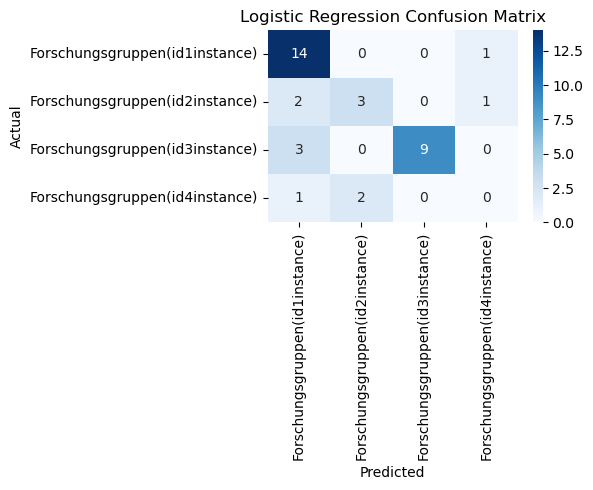

In [24]:
cm = confusion_matrix(y_test, test_predictions)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=label_encoder.classes_,
    yticklabels=label_encoder.classes_
)

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.title("Logistic Regression Confusion Matrix")

plt.tight_layout()
plt.savefig(FIGURES_DIR / "Logistic_Regression_matrix.png",dpi=300)

plt.show()

## Decision Tree Classifier

In [25]:
from sklearn.tree import DecisionTreeClassifier

In [26]:
# ============================================================
# Decision Tree Classifier
# ============================================================

decision_tree = DecisionTreeClassifier(
    class_weight="balanced",
    random_state=42
)

In [27]:
decision_tree.fit(X_train, y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current

In [28]:
train_predictions = decision_tree.predict(X_train)
test_predictions = decision_tree.predict(X_test)

In [29]:
print("=" * 60)
print("Decision Tree Performance")
print("=" * 60)

print("Training Accuracy :",
      accuracy_score(y_train, train_predictions))

print("Testing Accuracy  :",
      accuracy_score(y_test, test_predictions))

print()

print("Macro Precision :",
      precision_score(y_test, test_predictions, average="macro"))

print("Macro Recall    :",
      recall_score(y_test, test_predictions, average="macro"))

print("Macro F1 Score  :",
      f1_score(y_test, test_predictions, average="macro"))

Decision Tree Performance
Training Accuracy : 0.9285714285714286
Testing Accuracy  : 0.6944444444444444

Macro Precision : 0.513888888888889
Macro Recall    : 0.5083333333333333
Macro F1 Score  : 0.5053030303030304


In [30]:
print("\nClassification Report\n")

print(
    classification_report(
        y_test,
        test_predictions,
        target_names=label_encoder.classes_
    )
)


Classification Report

                                precision    recall  f1-score   support

Forschungsgruppen(id1instance)       0.72      0.87      0.79        15
Forschungsgruppen(id2instance)       0.50      0.33      0.40         6
Forschungsgruppen(id3instance)       0.83      0.83      0.83        12
Forschungsgruppen(id4instance)       0.00      0.00      0.00         3

                      accuracy                           0.69        36
                     macro avg       0.51      0.51      0.51        36
                  weighted avg       0.66      0.69      0.67        36



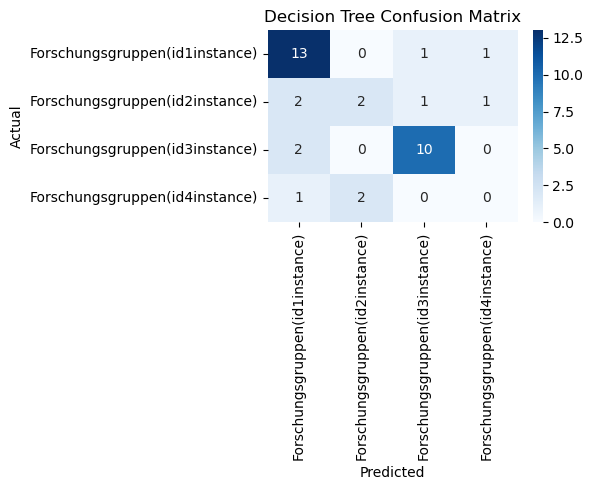

In [31]:
cm = confusion_matrix(y_test, test_predictions)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=label_encoder.classes_,
    yticklabels=label_encoder.classes_
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Decision Tree Confusion Matrix")

plt.tight_layout()
plt.savefig(FIGURES_DIR / "Decision_Tree_matrix.png",dpi=300)
plt.show()

## Random Forest Classifier

In [32]:
from sklearn.ensemble import RandomForestClassifier

In [33]:
# ============================================================
# Random Forest Classifier
# ============================================================

random_forest = RandomForestClassifier(
    n_estimators=200,
    class_weight="balanced",
    random_state=42
)

In [34]:
random_forest.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [35]:
train_predictions = random_forest.predict(X_train)
test_predictions = random_forest.predict(X_test)

In [36]:
print("=" * 60)
print("Random Forest Performance")
print("=" * 60)

print("Training Accuracy :",
      accuracy_score(y_train, train_predictions))

print("Testing Accuracy  :",
      accuracy_score(y_test, test_predictions))

print()

print("Macro Precision :",
      precision_score(y_test, test_predictions, average="macro"))

print("Macro Recall    :",
      recall_score(y_test, test_predictions, average="macro"))

print("Macro F1 Score  :",
      f1_score(y_test, test_predictions, average="macro"))

Random Forest Performance
Training Accuracy : 0.9285714285714286
Testing Accuracy  : 0.7222222222222222

Macro Precision : 0.6265182186234818
Macro Recall    : 0.525
Macro F1 Score  : 0.5308823529411765


In [37]:
print("\nClassification Report\n")

print(
    classification_report(
        y_test,
        test_predictions,
        target_names=label_encoder.classes_
    )
)


Classification Report

                                precision    recall  f1-score   support

Forschungsgruppen(id1instance)       0.74      0.93      0.82        15
Forschungsgruppen(id2instance)       1.00      0.33      0.50         6
Forschungsgruppen(id3instance)       0.77      0.83      0.80        12
Forschungsgruppen(id4instance)       0.00      0.00      0.00         3

                      accuracy                           0.72        36
                     macro avg       0.63      0.53      0.53        36
                  weighted avg       0.73      0.72      0.69        36



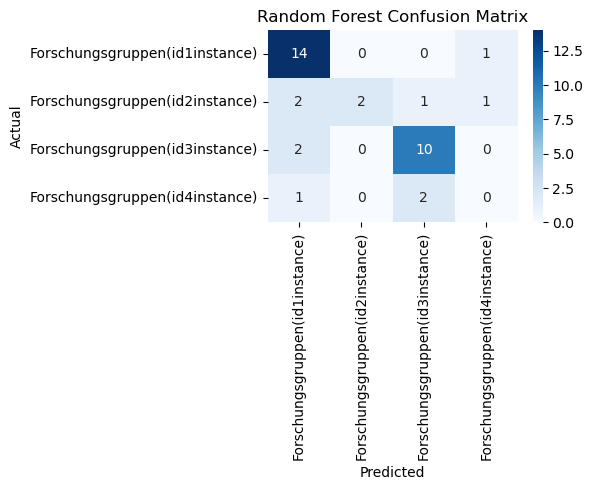

In [38]:
cm = confusion_matrix(y_test, test_predictions)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=label_encoder.classes_,
    yticklabels=label_encoder.classes_
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Random Forest Confusion Matrix")

plt.tight_layout()
plt.savefig(FIGURES_DIR / "Random_Forest_matrix.png",dpi=300)
plt.show()

## XGBoost Classifier

In [39]:
import xgboost

print(xgboost.__version__)

3.3.0


In [40]:
from xgboost import XGBClassifier

In [41]:
# ============================================================
# XGBoost Classifier
# ============================================================

xgb_model = XGBClassifier(
    objective="multi:softmax",
    num_class=4,
    n_estimators=200,
    max_depth=5,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

In [42]:
xgb_model.fit(X_train, y_train)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'multi:softmax'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.8
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from

In [43]:
train_predictions = xgb_model.predict(X_train)
test_predictions = xgb_model.predict(X_test)

In [44]:
print("=" * 60)
print("XGBoost Performance")
print("=" * 60)

print("Training Accuracy :",
      accuracy_score(y_train, train_predictions))

print("Testing Accuracy  :",
      accuracy_score(y_test, test_predictions))

print()

print("Macro Precision :",
      precision_score(y_test, test_predictions, average="macro"))

print("Macro Recall    :",
      recall_score(y_test, test_predictions, average="macro"))

print("Macro F1 Score  :",
      f1_score(y_test, test_predictions, average="macro"))

XGBoost Performance
Training Accuracy : 0.9285714285714286
Testing Accuracy  : 0.7222222222222222

Macro Precision : 0.5555555555555556
Macro Recall    : 0.55
Macro F1 Score  : 0.5492424242424242


In [45]:
print("\nClassification Report\n")

print(
    classification_report(
        y_test,
        test_predictions,
        target_names=label_encoder.classes_
    )
)


Classification Report

                                precision    recall  f1-score   support

Forschungsgruppen(id1instance)       0.72      0.87      0.79        15
Forschungsgruppen(id2instance)       0.50      0.50      0.50         6
Forschungsgruppen(id3instance)       1.00      0.83      0.91        12
Forschungsgruppen(id4instance)       0.00      0.00      0.00         3

                      accuracy                           0.72        36
                     macro avg       0.56      0.55      0.55        36
                  weighted avg       0.72      0.72      0.71        36



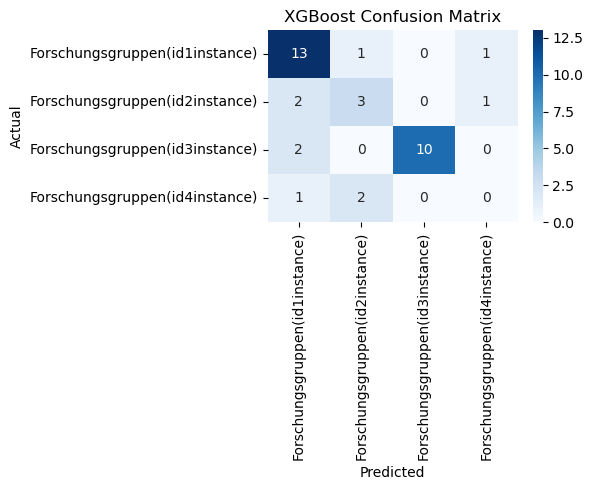

In [46]:
cm = confusion_matrix(y_test, test_predictions)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=label_encoder.classes_,
    yticklabels=label_encoder.classes_
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("XGBoost Confusion Matrix")

plt.tight_layout()
plt.savefig(FIGURES_DIR / "XGBoost_confusion_matrix.png",dpi=300)
plt.show()

# 6) Model Comparison and Select Best Model

In [47]:
# ============================================================
# Model Comparison
# ============================================================

model_results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest",
        "XGBoost"
    ],
    "Training Accuracy": [
        0.8643,
        0.9286,
        0.9286,
        0.9286
    ],
    "Testing Accuracy": [
        0.7500,
        0.7222,
        0.7500,
        0.7222
    ],
    "Macro Precision": [
        0.6958,
        0.6162,
        0.7259,
        0.5556
    ],
    "Macro Recall": [
        0.6292,
        0.5917,
        0.6083,
        0.5500
    ],
    "Macro F1": [
        0.6476,
        0.5977,
        0.6225,
        0.5492
    ]
})

model_results

,Model,Training Accuracy,Testing Accuracy,Macro Precision,Macro Recall,Macro F1
0,Logistic Regression,0.8643,0.7500,0.6958,0.6292,0.6476
1,Decision Tree,0.9286,0.7222,0.6162,0.5917,0.5977
2,Random Forest,0.9286,0.7500,0.7259,0.6083,0.6225
3,XGBoost,0.9286,0.7222,0.5556,0.5500,0.5492


In [48]:
model_results.sort_values(
    by="Testing Accuracy",
    ascending=False
)

,Model,Training Accuracy,Testing Accuracy,Macro Precision,Macro Recall,Macro F1
0,Logistic Regression,0.8643,0.7500,0.6958,0.6292,0.6476
2,Random Forest,0.9286,0.7500,0.7259,0.6083,0.6225
1,Decision Tree,0.9286,0.7222,0.6162,0.5917,0.5977
3,XGBoost,0.9286,0.7222,0.5556,0.5500,0.5492


**Conclusion:**

Finally selected the Random Forest model because good choice for the explainability notebook, and also the predictive performance is almost same with the Logistic Regression, and SHAP explanations will be richer and easier to visualize for the Random Forest.

In [49]:
model_results.to_csv(TABLES_DIR / "model_comparison.csv",index=False)

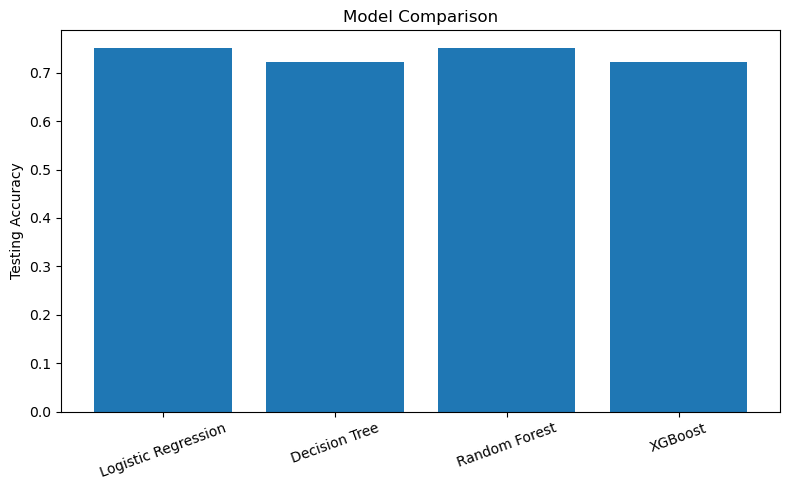

In [50]:
plt.figure(figsize=(8,5))

plt.bar(
    model_results["Model"],
    model_results["Testing Accuracy"]
)

plt.ylabel("Testing Accuracy")
plt.title("Model Comparison")

plt.xticks(rotation=20)

plt.savefig(FIGURES_DIR / "Model_Comparison.png", dpi=300)

plt.tight_layout()
plt.show()

## Save the Final Model

In [51]:
joblib.dump(random_forest, MODELS_DIR / "random_forest_model.pkl")

joblib.dump(logistic_model, MODELS_DIR / "logistic_regression_model.pkl")

joblib.dump(label_encoder, MODELS_DIR / "label_encoder.pkl")

['D:\\00000 Coding Restart 2025\\Explainable AI\\Explainable-AI-Mini-Project\\models\\label_encoder.pkl']